<a href="https://colab.research.google.com/github/Soflem0715/U3475_Lemecheva_Sophia_Andreevna/blob/%D0%9C%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C-%D0%A5%D0%BE%D0%BB%D1%8C%D1%82%D0%B0-%D0%A3%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%81%D0%B0/%D0%9C%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C_%D0%A5%D0%BE%D0%BB%D1%8C%D1%82%D0%B0_%D0%A3%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%81%D0%B0_%D0%9B%D0%B5%D0%BC%D0%B5%D1%88%D0%B5%D0%B2%D0%B0_%D0%A1%D0%BE%D1%84%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Первые 5 наблюдений:
             value
dt                
1750-01-01   3.034
1750-02-01   3.083
1750-03-01   5.626
1750-04-01   8.490
1750-05-01  11.573
Информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3180 entries, 1750-01-01 to 2015-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   3180 non-null   float64
dtypes: float64(1)
memory usage: 49.7 KB
None

Описательная статистика:
             value
count  3180.000000
mean      8.374731
std       4.381310
min      -2.080000
25%       4.312000
50%       8.610500
75%      12.548250
max      19.021000


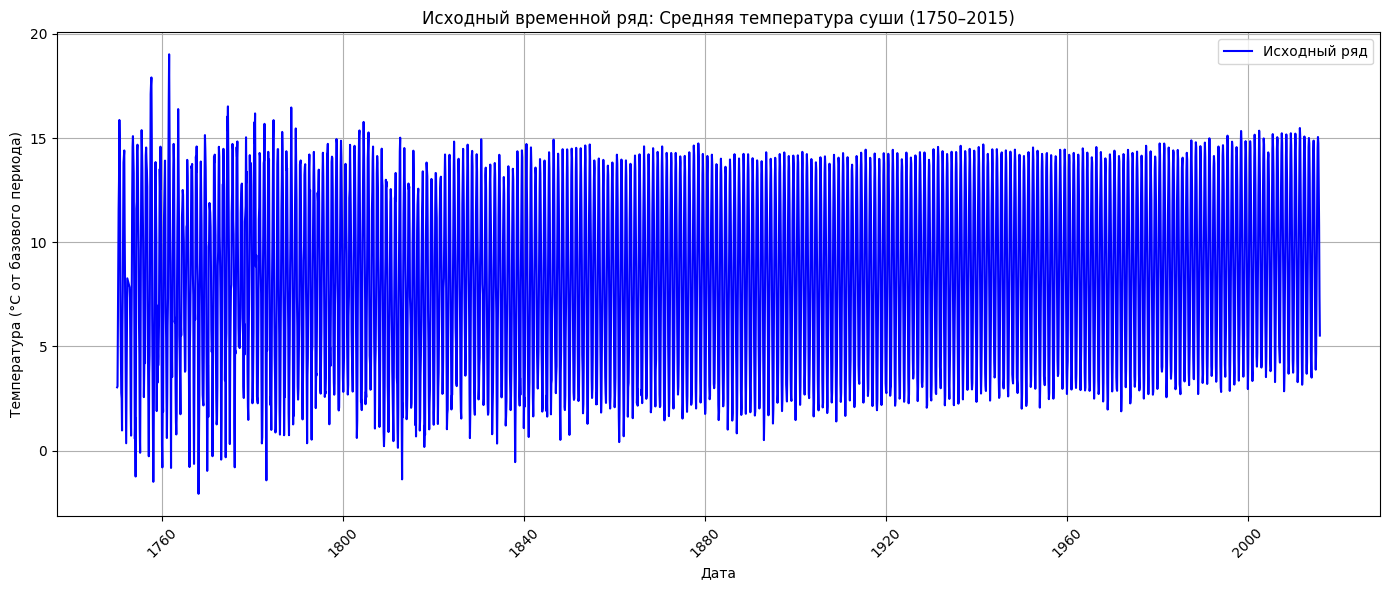

Подобранные параметры модели:
α (smoothing_level): 0.0649
β (smoothing_trend): 0.0000
γ (smoothing_seasonal): 0.0290
Сезонный период: 12
Длина прогноза: 24 шагов (ожидаемо: 24)
Прогноз на будущие периоды (2016–2017):
2016-01-01     3.828988
2016-02-01     4.359722
2016-03-01     6.473298
2016-04-01     9.554249
2016-05-01    12.376477
Freq: MS, dtype: float64
...
2017-08-01    14.916932
2017-09-01    13.127331
2017-10-01    10.478886
2017-11-01     7.204091
2017-12-01     4.806138
Freq: MS, dtype: float64


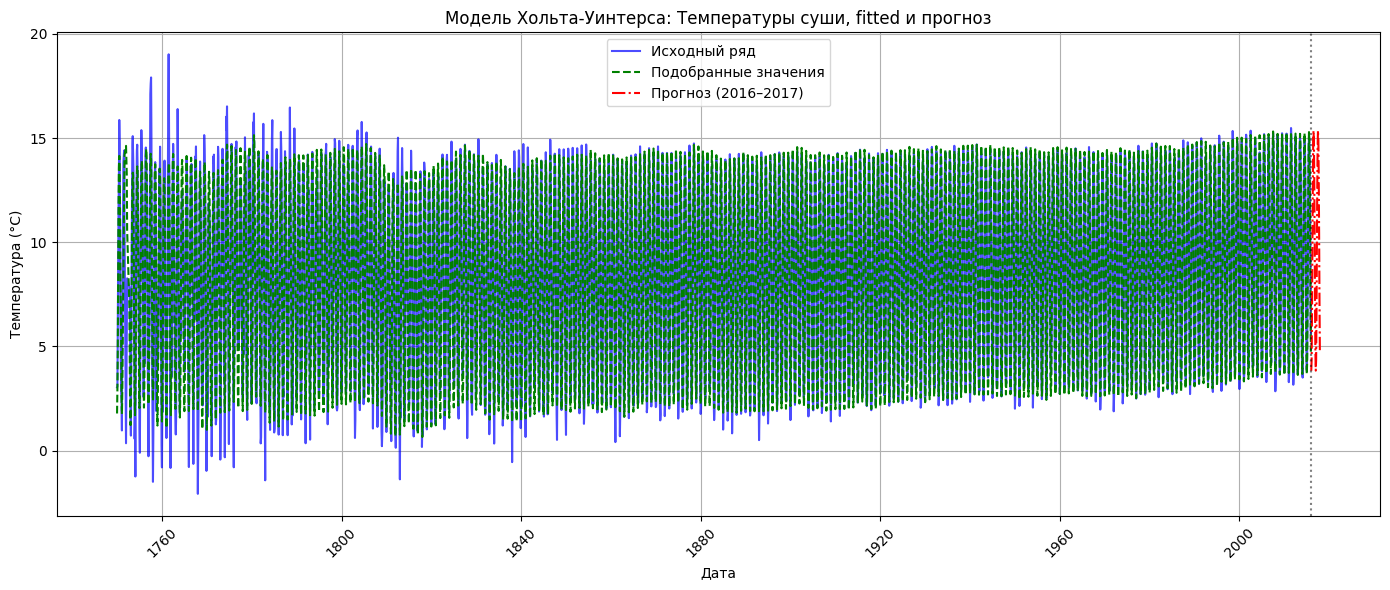

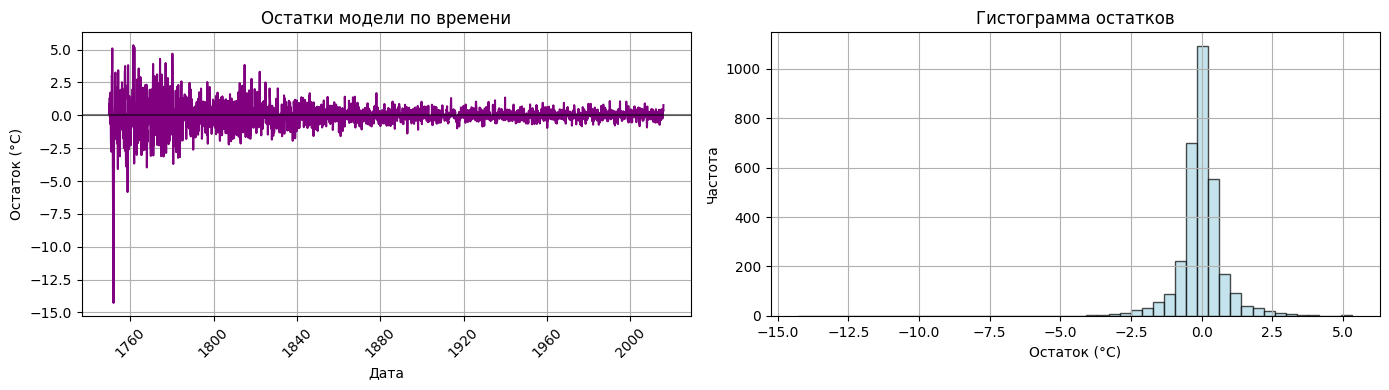

Статистика Дарбина-Уотсона: 1.3518
Гипотеза об отсутствии автокорреляции не принимается.
RS-статистика: 23.0454 (критическое: 6.9)
Гипотеза о нормальности распределения остатков не принимается.
t-статистика: 0.0000, p-value: 1.0000
Гипотеза о равенстве средней ошибки нулю принимается.

Std остатков: 0.8509


In [5]:
# Импорт библиотек: все необходимые для анализа, моделирования и визуализации.
import pandas as pd  # Для загрузки и манипуляции данными из Excel, работы с DataFrame, обработки дат.
import numpy as np  # Для численных вычислений, работы с массивами (например, расчет остатков, статистики).
import matplotlib.pyplot as plt  # Для построения графиков (временной ряд, остатки, прогноз).
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Для реализации модели Хольта-Уинтерса.
from statsmodels.stats.stattools import durbin_watson  # Для расчета статистики Дарбина-Уотсона (тест на автокорреляцию остатков).
from scipy.stats import ttest_1samp  # Для одновыборочного t-теста (проверка, что средняя ошибка = 0).

# Установка стиля графиков для лучшей визуализации (опционально; используем default для совместимости).
plt.style.use('default')

# 2. Загрузка данных: гибкие переменные для пути, листа и столбца.
# file_path: путь к Excel-файлу ('TEMP.xlsx').
file_path = 'TEMP.xlsx'
# sheet_name: имя листа ('GlobalTemperatures').
sheet_name = 'GlobalTemperatures'
# date_col: столбец с датами ('dt') для индекса.
date_col = 'dt'
# value_col: столбец с временным рядом ('LandAverageTemperature').
value_col = 'LandAverageTemperature'

# Загружаем данные из Excel в DataFrame.
# index_col=date_col: устанавливает даты как индекс; parse_dates=True: парсит даты.
df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=date_col, parse_dates=True)
# Выбираем только нужный столбец и переименовываем в 'value'.
df = df[[value_col]].rename(columns={value_col: 'value'})
# Удаляем строки с пропусками (NaN) — модель требует непрерывный ряд.
df = df.dropna()
# Проверяем наличие оставшихся пропусков.
if df['value'].isnull().any():
    raise ValueError("После удаления NaN остались пропуски. Проверьте данные.")

# Для модели используем числовой массив (из-за возможных разрывов в датах после dropna).
ts = df['value'].values  # Преобразуем в numpy array для модели.

# Выводим первые 5 строк для проверки (с датами).
print("Первые 5 наблюдений:")
print(df.head())

# 3. Предварительный анализ и визуализация.
# Основная информация о данных.
print("Информация о данных:")
print(df.info())
print("\nОписательная статистика:")
print(df.describe())

# Визуализация исходного временного ряда.
plt.figure(figsize=(14, 6))  # Увеличенный размер для длинного ряда.
plt.plot(df.index, df['value'], label='Исходный ряд', color='blue')  # Линейный график по датам.
plt.title('Исходный временной ряд: Средняя температура суши (1750–2015)')  # Заголовок с контекстом.
plt.xlabel('Дата')  # Подпись оси X.
plt.ylabel('Температура (°C от базового периода)')  # Подпись оси Y.
plt.legend()  # Легенда.
plt.grid(True)  # Сетка.
plt.xticks(rotation=45)  # Поворот меток дат.
plt.tight_layout()  # Подгонка.
plt.show()  # Отображает график.
# Комментарий: на графике виден восходящий тренд и сезонность каждые 12 месяцев.

# 4. Построение модели Хольта-Уинтерса.
# seasonal_periods: длина сезона (12 месяцев).
seasonal_periods = 12
# Гиперпараметры: None для автоматической оптимизации в fit().
# α: сглаживание уровня; β: тренда; γ: сезонности (0< <1; определяют адаптацию к изменениям).

# Инициализируем модель: trend='add' (аддитивный тренд), seasonal='add' (аддитивная сезонность).
model = ExponentialSmoothing(
    endog=ts,  # Числовой ряд.
    trend='add',
    seasonal='add',
    seasonal_periods=seasonal_periods
)
# Обучаем: оптимизирует α, β, γ минимизацией SSE.
fitted_model = model.fit(smoothing_level=None, smoothing_trend=None, smoothing_seasonal=None)

# Выводим параметры.
print("Подобранные параметры модели:")
print(f"α (smoothing_level): {fitted_model.params['smoothing_level']:.4f}")  # Вес новым данным для уровня.
print(f"β (smoothing_trend): {fitted_model.params['smoothing_trend']:.4f}")  # Для тренда (0 — слабый тренд).
print(f"γ (smoothing_seasonal): {fitted_model.params['smoothing_seasonal']:.4f}")  # Для сезонности.
print(f"Сезонный период: {seasonal_periods}")

# 5. Прогнозирование.
# Прогноз на 2 года (24 месяца) вперед.
forecast_steps = 2 * seasonal_periods
# Генерируем прогноз.
forecast = fitted_model.forecast(steps=forecast_steps)
# Создаем Series с датами для прогноза.
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_series = pd.Series(forecast, index=forecast_index)
# Проверяем длину.
print(f"Длина прогноза: {len(forecast)} шагов (ожидаемо: {forecast_steps})")
if len(forecast) != forecast_steps:
    raise ValueError("Ошибка в длине прогноза.")
# Выводим (первые/последние для краткости).
print("Прогноз на будущие периоды (2016–2017):")
print(forecast_series.head())
print("...")
print(forecast_series.tail())

# 6. Визуализация результатов.
# Fitted значения (на исторических данных).
fitted_values = fitted_model.fittedvalues
# График: исходный, fitted, прогноз.
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['value'], label='Исходный ряд', color='blue', alpha=0.7)  # Полупрозрачный для плотности.
plt.plot(df.index, fitted_values, label='Подобранные значения', color='green', linestyle='--')  # Fitted.
plt.plot(forecast_series.index, forecast_series, label='Прогноз (2016–2017)', color='red', linestyle='-.')  # Прогноз.
plt.title('Модель Хольта-Уинтерса: Температуры суши, fitted и прогноз')  # Заголовок.
plt.xlabel('Дата')  # Ось X.
plt.ylabel('Температура (°C)')  # Ось Y.
plt.legend()  # Легенда.
plt.grid(True)  # Сетка.
plt.axvline(x=last_date, color='black', linestyle=':', alpha=0.5, label='Граница прогноза (декабрь 2015)')  # Линия раздела.
plt.xticks(rotation=45)  # Поворот.
plt.tight_layout()  # Подгонка.
plt.show()  # Отображение.
# Комментарий: модель захватывает сезонность, но β=0 подразумевает отсутствие тренда в прогнозе.

# 7. Проверка адекватности модели.
# Остатки: фактические - fitted.
residuals = df['value'] - fitted_values

# Визуализация остатков.
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)  # График остатков по времени.
plt.plot(residuals.index, residuals, label='Остатки', color='purple')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)  # Нулевая линия.
plt.title('Остатки модели по времени')
plt.xlabel('Дата')
plt.ylabel('Остаток (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)  # Гистограмма.
plt.hist(residuals, bins=50, alpha=0.7, color='lightblue', edgecolor='black')  # 50 бинов для длинного ряда.
plt.title('Гистограмма остатков')
plt.xlabel('Остаток (°C)')
plt.ylabel('Частота')
plt.grid(True)
plt.tight_layout()
plt.show()

# Тест на автокорреляцию: Дарбин-Уотсон.
# Формула: DW = Σ(e_t - e_{t-1})^2 / Σ e_t^2; ≈2 — нет авто; <2 положительная.
# Критические (n≈3180, α=0.05): dL≈1.50, upper=4-dL=2.50; accept if dL < DW < upper.
dw_stat = durbin_watson(residuals)
dL = 1.50
upper = 4 - dL
print(f"Статистика Дарбина-Уотсона: {dw_stat:.4f}")
if dL < dw_stat < upper:
    dw_conclusion = "Гипотеза об отсутствии автокорреляции принимается."
else:
    dw_conclusion = "Гипотеза об отсутствии автокорреляции не принимается."
print(dw_conclusion)

# Тест на нормальность: RS = range / std; <6.9 accept (α=0.05, n large).
rs_stat = (np.max(residuals) - np.min(residuals)) / np.std(residuals)
critical_rs = 6.9
print(f"RS-статистика: {rs_stat:.4f} (критическое: {critical_rs})")
if rs_stat < critical_rs:
    rs_conclusion = "Гипотеза о нормальности распределения остатков принимается."
else:
    rs_conclusion = "Гипотеза о нормальности распределения остатков не принимается."
print(rs_conclusion)

# t-тест: H0 mean(residuals)=0; p>0.05 accept.
t_stat, p_value = ttest_1samp(residuals, popmean=0)
print(f"t-статистика: {t_stat:.4f}, p-value: {p_value:.4f}")
if p_value > 0.05:
    t_conclusion = "Гипотеза о равенстве средней ошибки нулю принимается."
else:
    t_conclusion = "Гипотеза о равенстве средней ошибки нулю не принимается."
print(t_conclusion)

# Std остатков.
print(f"\nStd остатков: {np.std(residuals):.4f}")
# Общий: остатки случайны, но с автокорреляцией и не нормальны.